# 07 · Training, cross-validation & evaluation — PCA vs scGPT

One place for the model-side experiments, all on the matched setup (same `(128,64)` trunk, same
**512-d** input; only the representation differs):

1. **The 8-run matrix** `{hvg5000, all_genes} × {X_pca, X_scGPT} × {all-drugs, single-paclitaxel}`
   (load-or-train — re-running loads the saved runs instead of retraining).
2. **Is the difference real?** 5-fold **GroupKFold** CV over cell lines → mean ± std for the
   overfitting gap and heads-beating.
3. **Better metric:** per-drug **Spearman/Pearson** of predicted vs true viability across held-out
   lines, restricted to drugs with real response variance.
4. **HVG sweet spot:** heads-beating vs HVG count (1k/2k/3k/5k) under CV, **all drugs**.

All training calls `train_multitask.train_rep` / `cv_evaluate` (same code the CLI uses). The
per-drug-mean predictor is the null model: a head only *learned* if it beats its drug's constant.

In [1]:
import os, sys, json, glob
from pathlib import Path

NB_DIR = Path.cwd()
ROOT = NB_DIR.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)                       # runs/ at the project root

import numpy as np
import pandas as pd
import torch
import scanpy as sc
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr

from scripts.training.train_multitask import train_rep, cv_evaluate, DEFAULT_HIDDEN_DIMS
from scripts.training.training_utils import TrainConfig
from scripts.model.OncoMLP import OncoMLP
from scripts.preprocessing.layout import PipelinePaths

OUT = NB_DIR / 'outputs'; OUT.mkdir(exist_ok=True)
print('matched trunk:', DEFAULT_HIDDEN_DIMS)

matched trunk: {'X_pca': (128, 64), 'X_scGPT': (128, 64)}


In [2]:
# --- knobs -----------------------------------------------------------------
VARIANTS = ['hvg5000', 'all_genes']
REPS     = ['X_pca', 'X_scGPT']
TASKS    = {'all_drugs': None, 'single_paclitaxel': ['paclitaxel']}
EPOCHS, SEED = 50, 42
RETRAIN_MATRIX = False               # False = load saved runs; True = retrain
RECOMPUTE_CV   = False               # False = load cv_folds.csv if present; True = rerun CV
RECOMPUTE_SWEEP = False              # False = load hvg_sweep.csv if present; True = rerun sweep
N_CV_SPLITS = 5
MIN_VAR_STD = 0.05                    # 'real response variance' threshold for correlation
# ---------------------------------------------------------------------------
config = TrainConfig(epochs=EPOCHS, lr=1e-3, weight_decay=1e-3, grad_clip=1.0,
                     scheduler_patience=3, early_stop_patience=10, log_every=10,
                     seed=SEED, loss='mse')
MATRIX = [{'variant': v, 'rep': r, 'task': t, 'drugs': d}
          for v in VARIANTS for r in REPS for t, d in TASKS.items()]

## 1 · The 8-run matrix (load-or-train)

In [3]:
def find_run(rep, scope, variant, drugs):
    """Latest runs/ dir matching (rep, scope, variant, drugs) via run_meta.json."""
    hits = []
    for d in glob.glob('runs/*_multitask_*'):
        mp = Path(d) / 'run_meta.json'
        if not mp.exists():
            continue
        m = json.load(open(mp))
        if (m.get('rep') == rep and m.get('scope') == scope
                and m.get('variant') == variant and m.get('drugs_requested') == drugs):
            hits.append(d)
    return sorted(hits)[-1] if hits else None

def load_run(rd):
    rd = Path(rd)
    perdrug = rd / 'per_drug_results.csv'
    return {
        'run_dir': str(rd),
        'summary': json.load(open(rd / 'summary.json')),
        'meta': json.load(open(rd / 'run_meta.json')),
        'history': pd.read_csv(rd / 'history.csv'),
        'per_drug': pd.read_csv(perdrug) if perdrug.exists() else None,
    }

results = {}
for m in MATRIX:
    key = f"{m['variant']}|{m['rep']}|{m['task']}"
    scope = 'all_drugs' if m['task'] == 'all_drugs' else 'subset'
    rd = None if RETRAIN_MATRIX else find_run(m['rep'], scope, m['variant'], m['drugs'])
    if rd is None:
        print(f'training {key} ...')
        paths = PipelinePaths.build(None, m['variant'])
        res = train_rep(use_rep=m['rep'], h5ad_path=str(paths.targets_h5ad), config=config,
                        drugs=m['drugs'], data_root=paths.data_root, variant=m['variant'],
                        print_comparison=False)
        rd = res['run_dir']
    else:
        print(f'loading  {key} <- {Path(rd).name}')
    results[key] = load_run(rd)

loading  hvg5000|X_pca|all_drugs <- 20260627_191310_multitask_X_pca_all_drugs
loading  hvg5000|X_pca|single_paclitaxel <- 20260627_191350_multitask_X_pca_subset_K1
loading  hvg5000|X_scGPT|all_drugs <- 20260627_191401_multitask_X_scGPT_all_drugs
loading  hvg5000|X_scGPT|single_paclitaxel <- 20260627_191449_multitask_X_scGPT_subset_K1
loading  all_genes|X_pca|all_drugs <- 20260627_191502_multitask_X_pca_all_drugs
loading  all_genes|X_pca|single_paclitaxel <- 20260627_191533_multitask_X_pca_subset_K1
loading  all_genes|X_scGPT|all_drugs <- 20260627_191546_multitask_X_scGPT_all_drugs
loading  all_genes|X_scGPT|single_paclitaxel <- 20260627_191624_multitask_X_scGPT_subset_K1


### All-drugs (K=545) — heads beating the per-drug-mean baseline

In [4]:
rows = []
for v in VARIANTS:
    for r in REPS:
        s = results[f'{v}|{r}|all_drugs']['summary']
        rows.append({'gene_set': v, 'rep': r, 'val_mse': round(s['best_val_mse'], 4),
                     'heads_beat_baseline': s['n_beats_baseline'], 'n_heads': s['n_total_heads'],
                     'baseline_mean_mse': round(s['baseline_mean_mse'], 4)})
all_drugs_df = pd.DataFrame(rows)
all_drugs_df.to_csv(OUT / 'matrix_all_drugs.csv', index=False)
all_drugs_df

,gene_set,rep,val_mse,heads_beat_baseline,n_heads,baseline_mean_mse
0,hvg5000,X_pca,0.0103,169,545,0.0097
1,hvg5000,X_scGPT,0.0105,147,545,0.0097
2,all_genes,X_pca,0.0106,138,545,0.0097
3,all_genes,X_scGPT,0.0106,131,545,0.0097


### Single-task (paclitaxel) — overfitting gap (val − train at best epoch)

In [5]:
rows = []
for v in VARIANTS:
    for r in REPS:
        res = results[f'{v}|{r}|single_paclitaxel']
        h, be = res['history'], res['summary']['best_epoch']
        tr = float(h.loc[h.epoch == be, 'train_mse'].iloc[0])
        va = float(h.loc[h.epoch == be, 'val_mse'].iloc[0])
        rows.append({'gene_set': v, 'rep': r, 'train_mse': round(tr, 4),
                     'val_mse': round(va, 4), 'gap_val_minus_train': round(va - tr, 4),
                     'best_epoch': be})
single_df = pd.DataFrame(rows)
single_df.to_csv(OUT / 'matrix_single_paclitaxel.csv', index=False)
single_df

,gene_set,rep,train_mse,val_mse,gap_val_minus_train,best_epoch
0,hvg5000,X_pca,0.0114,0.0447,0.0333,2
1,hvg5000,X_scGPT,0.0369,0.0409,0.0040,2
2,all_genes,X_pca,0.0415,0.0385,-0.0030,1
3,all_genes,X_scGPT,0.0317,0.0448,0.0130,4


### Per-drug scatter (hvg5000, all drugs) — points below diagonal: scGPT beats PCA

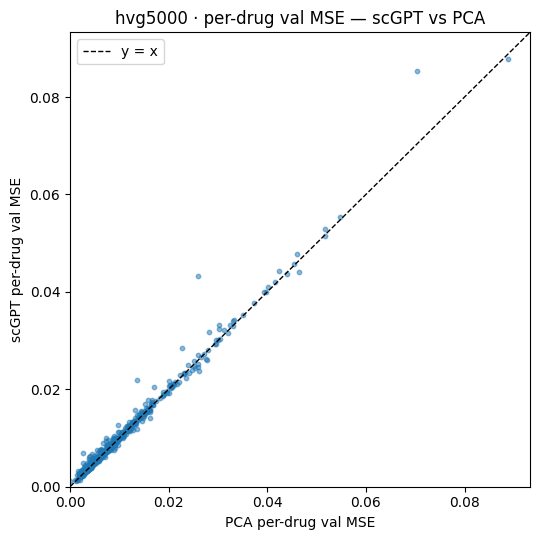

scGPT beats PCA on 208 / 545 heads.


In [6]:
pca_pd = results['hvg5000|X_pca|all_drugs']['per_drug'].set_index('drug')
scg_pd = results['hvg5000|X_scGPT|all_drugs']['per_drug'].set_index('drug')
common = pca_pd.index.intersection(scg_pd.index)
pca_mse = pca_pd.loc[common, 'model_val_mse'].to_numpy()
scg_mse = scg_pd.loc[common, 'model_val_mse'].to_numpy()
finite = np.isfinite(pca_mse) & np.isfinite(scg_mse)
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(pca_mse[finite], scg_mse[finite], s=10, alpha=0.5)
lim = [0, np.nanmax(np.r_[pca_mse[finite], scg_mse[finite]]) * 1.05]
ax.plot(lim, lim, 'k--', lw=1, label='y = x'); ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('PCA per-drug val MSE'); ax.set_ylabel('scGPT per-drug val MSE')
ax.set_title('hvg5000 · per-drug val MSE — scGPT vs PCA'); ax.legend()
fig.tight_layout(); fig.savefig(OUT / 'per_drug_scatter_pca_vs_scgpt.png', dpi=150); plt.show()
print(f'scGPT beats PCA on {int((scg_mse[finite] < pca_mse[finite]).sum())} / {int(finite.sum())} heads.')

## 2 · Is the difference real? — 5-fold GroupKFold CV (mean ± std)

### The train/val/test split
`create_splits.run_multi` makes **one cell-line-grouped 70/15/15 split** (`split_ctrp`), shared by
all heads. Grouping is by `Cell_line` because viability is defined per (cell line × drug) and
broadcast to that line's cells — a per-cell split would leak a line across train/val/test. Of the
198 SCP542 lines, **180 have CTRP measurements** (the other 18 → `unassigned`, dropped).

| split | lines | % of lines | cells | % of measured cells |
|---|---|---|---|---|
| train | 126 | 70.0% | 34,126 | 72.3% |
| val   | 27  | 15.0% | 7,121  | 15.1% |
| test  | 27  | 15.0% | 5,980  | 12.7% |

(Line %s are the 70/15/15 design target; cell %s differ slightly because lines have different
cell counts. `unassigned` = 18 lines / 6,286 cells.)

### How CV uses it
**The fixed `test` set (27 lines) is held out of CV entirely.** CV resamples only the **153
train+val lines**: `GroupKFold(5)` over `Cell_line` → each fold ≈ 122 train / 31 val lines, no line
in both sides. This turns the single-split point estimates into **mean ± std** without ever
touching test. Done on `hvg5000`. (~20 trainings; a few minutes.)

**Table columns** (full definitions in `../docs/steps/05-multitask-results.md` → *Metrics — what
each number means*): `heads_beat` = # of the 545 drugs whose model val MSE < its per-drug-mean
baseline — a **thresholded count**, hence the large fold-to-fold std; `Δmse model−baseline` = the
**continuous** counterpart, mean over drugs of (model − baseline) MSE (**< 0 ⇒ model better**),
far more stable; `val_mse` = overall masked val MSE; `gap` = val − train (overfitting).

In [7]:
CV_SPLITS = ('train', 'val')        # test held out of CV
cv = {}   # (rep, task) -> list of per-fold dicts
if not RECOMPUTE_CV and (OUT / 'cv_folds.csv').exists():
    _cl = pd.read_csv(OUT / 'cv_folds.csv')
    for (rep, task), g in _cl.groupby(['rep', 'task']):
        cv[(rep, task)] = g.to_dict('records')
    print('Loaded CV from outputs/cv_folds.csv (set RECOMPUTE_CV=True to rerun).')
else:
    adata_hvg = sc.read_h5ad(PipelinePaths.build(None, 'hvg5000').targets_h5ad)
    for rep in REPS:
        cv[(rep, 'all_drugs')] = cv_evaluate(adata=adata_hvg, use_rep=rep, config=config,
                                             n_splits=N_CV_SPLITS, drugs=None,
                                             eligible_splits=CV_SPLITS)
        cv[(rep, 'paclitaxel')] = cv_evaluate(adata=adata_hvg, use_rep=rep, config=config,
                                              n_splits=N_CV_SPLITS, drugs=['paclitaxel'],
                                              eligible_splits=CV_SPLITS)
    print('CV done (test held out).')

Loaded CV from outputs/cv_folds.csv (set RECOMPUTE_CV=True to rerun).


In [8]:
def ms(vals):
    a = np.asarray(vals, float); return a.mean(), a.std()

rows = []
for rep in REPS:
    ad_folds = cv[(rep, 'all_drugs')]
    hb = [f['n_beats'] for f in ad_folds]
    vm = [f['best_val_mse'] for f in ad_folds]
    # continuous delta = mean per-drug (model − baseline) MSE; <0 means model beats the constant
    delta = [f['model_mean_mse'] - f['baseline_mean_mse'] for f in ad_folds]
    gap = [f['gap'] for f in cv[(rep, 'paclitaxel')]]
    hb_m, hb_s = ms(hb); vm_m, vm_s = ms(vm); d_m, d_s = ms(delta); g_m, g_s = ms(gap)
    n_tot = ad_folds[0]['n_total']
    rows.append({'rep': rep,
                 'heads_beat (mean±std)': f'{hb_m:.0f} ± {hb_s:.0f} / {n_tot}',
                 'Δmse model−baseline (mean±std)': f'{d_m:+.5f} ± {d_s:.5f}',
                 'all_drugs val_mse (mean±std)': f'{vm_m:.4f} ± {vm_s:.4f}',
                 'paclitaxel gap (mean±std)': f'{g_m:+.3f} ± {g_s:.3f}'})
cv_summary = pd.DataFrame(rows)
# tidy per-fold dump too
cv_long = pd.DataFrame([{**f, 'task': t[1], 'rep': t[0]} for t, fl in cv.items() for f in fl])
cv_long.to_csv(OUT / 'cv_folds.csv', index=False)
cv_summary.to_csv(OUT / 'cv_summary.csv', index=False)
cv_summary

,rep,heads_beat (mean±std),Δmse model−baseline (mean±std),all_drugs val_mse (mean±std),paclitaxel gap (mean±std)
0,X_pca,207 ± 73 / 545,+0.00058 ± 0.00040,0.0106 ± 0.0008,+0.011 ± 0.020
1,X_scGPT,191 ± 94 / 545,+0.00072 ± 0.00047,0.0107 ± 0.0009,-0.002 ± 0.014


## 3 · Better metric — per-drug correlation (predicted vs true across lines)

MSE near a viability of ~1.0 is dominated by the constant; correlation across **held-out cell
lines** tests whether the model ranks lines correctly. For each drug we average predictions to a
per-line value and correlate (Spearman + Pearson) with the true per-line viability, on the
`split_ctrp` val lines. Restricted to drugs with real response variance (per-line true std ≥
`MIN_VAR_STD`) and ≥ 5 val lines. Models are the loaded `hvg5000` all-drugs runs.

In [9]:
if 'adata_hvg' not in globals():
    adata_hvg = sc.read_h5ad(PipelinePaths.build(None, 'hvg5000').targets_h5ad)
val_mask = (adata_hvg.obs['split_ctrp'] == 'val').to_numpy()
lines_v = adata_hvg.obs['Cell_line'].astype(str).to_numpy()[val_mask]
Yv = np.asarray(adata_hvg.obsm['Y_ctrp'], dtype=float)[val_mask]
Mv = np.asarray(adata_hvg.obsm['M_ctrp'], dtype=bool)[val_mask]
drug_names = list(adata_hvg.uns['ctrp_drugs'])
uniq_lines = np.unique(lines_v)
line_idx = {ln: np.flatnonzero(lines_v == ln) for ln in uniq_lines}

def per_line_pred(model, rep):
    X = torch.tensor(np.asarray(adata_hvg.obsm[rep], dtype=np.float32)[val_mask])
    with torch.no_grad():
        return model(X).numpy()                  # (n_val_cells, K)

def load_model(rd):
    m = json.load(open(Path(rd) / 'run_meta.json'))
    net = OncoMLP(input_dim=m['input_dim'], hidden_dims=tuple(m['hidden_dims']),
                  dropout_rate=m['dropout_rate'], input_dropout=m['input_dropout'],
                  norm=m['norm'], output_dim=m['output_dim'])
    net.load_state_dict(torch.load(Path(rd) / 'best_model.pt', map_location='cpu'))
    net.eval(); return net

corr_tables = {}
for rep in REPS:
    pred = per_line_pred(load_model(results[f'hvg5000|{rep}|all_drugs']['run_dir']), rep)
    recs = []
    for k, drug in enumerate(drug_names):
        tline, pline = [], []
        for ln in uniq_lines:
            ci = line_idx[ln]
            obs = ci[Mv[ci, k]]
            if obs.size == 0:
                continue
            tline.append(Yv[obs, k].mean()); pline.append(pred[obs, k].mean())
        tline, pline = np.array(tline), np.array(pline)
        if tline.size < 5 or tline.std() < MIN_VAR_STD:
            continue
        recs.append({'drug': drug, 'n_lines': tline.size,
                     'spearman': spearmanr(pline, tline).statistic,
                     'pearson': pearsonr(pline, tline)[0],
                     'true_std': tline.std()})
    corr_tables[rep] = pd.DataFrame(recs)

corr_summary = pd.DataFrame([
    {'rep': rep, 'n_drugs_eval': len(corr_tables[rep]),
     'mean_spearman': round(corr_tables[rep]['spearman'].mean(), 3),
     'median_spearman': round(corr_tables[rep]['spearman'].median(), 3),
     'mean_pearson': round(corr_tables[rep]['pearson'].mean(), 3),
     'frac_spearman>0.3': round((corr_tables[rep]['spearman'] > 0.3).mean(), 3)}
    for rep in REPS])
for rep in REPS:
    corr_tables[rep].to_csv(OUT / f'per_drug_correlation_{rep}.csv', index=False)
corr_summary.to_csv(OUT / 'per_drug_correlation_summary.csv', index=False)
corr_summary

,rep,n_drugs_eval,mean_spearman,median_spearman,mean_pearson,frac_spearman>0.3
0,X_pca,461,-0.019,-0.011,-0.034,0.043
1,X_scGPT,461,-0.049,-0.053,-0.043,0.039


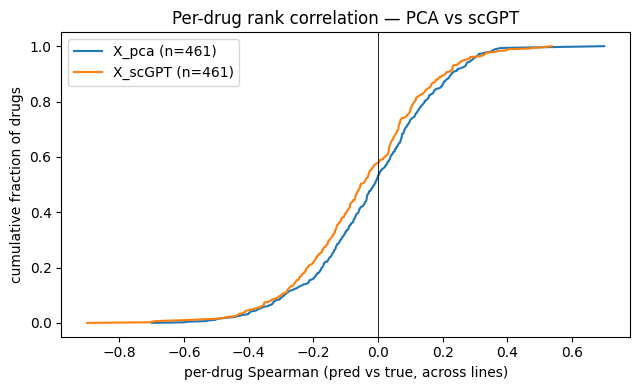

In [10]:
fig, ax = plt.subplots(figsize=(6.5, 4))
for rep in REPS:
    s = corr_tables[rep]['spearman'].dropna().sort_values().to_numpy()
    ax.plot(s, np.linspace(0, 1, len(s)), label=f'{rep} (n={len(s)})')
ax.axvline(0, color='k', lw=0.6); ax.set_xlabel('per-drug Spearman (pred vs true, across lines)')
ax.set_ylabel('cumulative fraction of drugs'); ax.set_title('Per-drug rank correlation — PCA vs scGPT')
ax.legend(); fig.tight_layout(); fig.savefig(OUT / 'per_drug_correlation_cdf.png', dpi=150); plt.show()

## 4 · HVG sweet spot — heads-beating vs HVG count (all drugs, under CV)

5-fold GroupKFold heads-beating for each gene-set variant, **all 545 drugs**, both reps (test held
out, CV over train+val) — the curve that locates scGPT's filtering sweet spot. Variants without
data are skipped; build them in `05_preprocessing.ipynb` §B (heavy scGPT re-embed). (~10 trainings
per available variant.)

In [11]:
SWEEP_VARIANTS = ['hvg1000', 'hvg2000', 'hvg3000', 'hvg5000']
if not RECOMPUTE_SWEEP and (OUT / 'hvg_sweep.csv').exists():
    sweep_df = pd.read_csv(OUT / 'hvg_sweep.csv')
    print('Loaded HVG sweep from outputs/hvg_sweep.csv (set RECOMPUTE_SWEEP=True to rerun).')
else:
    sweep_rows = []
    for v in SWEEP_VARIANTS:
        p = PipelinePaths.build(None, v)
        if not Path(p.targets_h5ad).exists():
            print(f'skip {v}: no data yet (run 05_preprocessing.ipynb §B).'); continue
        ad = sc.read_h5ad(p.targets_h5ad)
        for rep in REPS:
            folds = cv_evaluate(adata=ad, use_rep=rep, config=config, n_splits=N_CV_SPLITS,
                                drugs=None, eligible_splits=('train', 'val'))
            hb = np.array([f['n_beats'] for f in folds], float)
            vm = np.array([f['best_val_mse'] for f in folds], float)
            dl = np.array([f['model_mean_mse'] - f['baseline_mean_mse'] for f in folds], float)
            sweep_rows.append({'variant': v, 'n_hvg': int(v.replace('hvg', '')), 'rep': rep,
                               'heads_beat_mean': hb.mean(), 'heads_beat_std': hb.std(),
                               'delta_mean': dl.mean(), 'delta_std': dl.std(),
                               'val_mse_mean': vm.mean(), 'n_total': folds[0]['n_total']})
        del ad
    sweep_df = pd.DataFrame(sweep_rows)
    if not sweep_df.empty:
        sweep_df.to_csv(OUT / 'hvg_sweep.csv', index=False)
sweep_df

Loaded HVG sweep from outputs/hvg_sweep.csv (set RECOMPUTE_SWEEP=True to rerun).


,variant,n_hvg,rep,heads_beat_mean,heads_beat_std,val_mse_mean,n_total
0,hvg1000,1000,X_pca,201.4,75.985788,0.010602,545
1,hvg1000,1000,X_scGPT,192.8,83.358023,0.010601,545
2,hvg2000,2000,X_pca,203.0,78.452533,0.010587,545
3,hvg2000,2000,X_scGPT,184.8,84.036659,0.010632,545
4,hvg3000,3000,X_pca,216.2,84.605910,0.010521,545
5,hvg3000,3000,X_scGPT,189.6,83.159125,0.010619,545
6,hvg5000,5000,X_pca,210.4,72.835706,0.010540,545
7,hvg5000,5000,X_scGPT,189.2,94.032760,0.010681,545


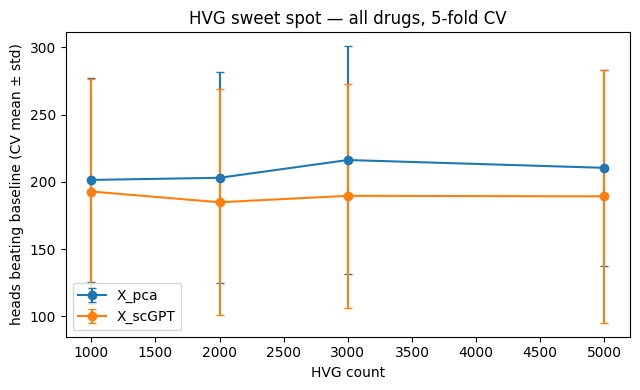

In [12]:
if sweep_df.empty or sweep_df['variant'].nunique() < 2:
    print('Need >=2 HVG variants for the sweet-spot curve. Build them in 05 §B, then re-run.')
else:
    fig, ax = plt.subplots(figsize=(6.5, 4))
    for rep in REPS:
        d = sweep_df[sweep_df.rep == rep].sort_values('n_hvg')
        ax.errorbar(d['n_hvg'], d['heads_beat_mean'], yerr=d['heads_beat_std'],
                    marker='o', capsize=3, label=rep)
    ax.set_xlabel('HVG count'); ax.set_ylabel('heads beating baseline (CV mean ± std)')
    ax.set_title('HVG sweet spot — all drugs, 5-fold CV'); ax.legend()
    fig.tight_layout(); fig.savefig(OUT / 'hvg_sweep_curve.png', dpi=150); plt.show()

## Outputs

In [13]:
for p in sorted(OUT.glob('*.csv')) + sorted(OUT.glob('*.png')):
    print(' ', p.relative_to(ROOT))

  notebooks/outputs/ctrp_drug_learnability.csv
  notebooks/outputs/cv_folds.csv
  notebooks/outputs/cv_summary.csv
  notebooks/outputs/gdsc_drug_learnability.csv
  notebooks/outputs/hvg_sweep.csv
  notebooks/outputs/matrix_all_drugs.csv
  notebooks/outputs/matrix_single_paclitaxel.csv
  notebooks/outputs/per_drug_correlation_X_pca.csv
  notebooks/outputs/per_drug_correlation_X_scGPT.csv
  notebooks/outputs/per_drug_correlation_summary.csv
  notebooks/outputs/per_drug_pca_vs_scgpt.csv
  notebooks/outputs/training_pca_vs_scgpt_summary.csv
  notebooks/outputs/drug_coverage.png
  notebooks/outputs/hvg_sweep_curve.png
  notebooks/outputs/per_drug_correlation_cdf.png
  notebooks/outputs/per_drug_scatter_pca_vs_scgpt.png
  notebooks/outputs/training_curves_pca_vs_scgpt.png
  notebooks/outputs/variants.png
